In [34]:
import numpy as np
import pandas as pd
import kiauhoku as kh

In [35]:
def lnprior(theta):
    return 0

def lnlike(theta, grid, data, sigma):
    mass, met, alpha, logg = theta   # unpack parameters
    star = grid.get_star_eep(theta)
    if star.isnull().any():
        return -np.inf, None

    teff = 10**star['Log Teff(K)']
    star['Teff(K)'] = teff

    z_x_surf = np.log10(star['Z/X(surf)']/0.02289)
    star['[Z/X]'] = z_x_surf
    star['[alpha/Z]'] = alpha

    log_g = star['logg']

    # add the walker params to the star so we can plot them later
    star['initial mass'] = mass
    star['initial [M/H]'] = met
    star['initial [alpha/M]'] = alpha
    
    theta_ = np.array([teff, z_x_surf, alpha, logg])
    my_log_like = lnChiSq(theta_, data, sigma)
    return my_log_like, star


def lnChiSq(theta, data, sigma):
    return -0.5 * (((theta-data)/sigma)**2).sum()

In [36]:
def lnprob(theta, grid, data, sigma):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf, None

    ll, star = lnlike(theta, grid, data, sigma)

    if not np.isfinite(ll):
        return -np.inf, None

    my_log_prob = lp + ll
    star["lnprob"] = my_log_prob

    return my_log_prob, star

In [70]:
sun_data = np.array([5776, 0, 0, 4.437])
sun_sigma = np.array([100, 0.1, 0.1, 0.005])
args = (sun_data, sun_sigma)

# tuple is same shape as grid index (initial mass, initial metallicity, initial alpha, log g)
initial_guess = (1, 0, 0.2, 3.5)
guess_width = (0.2, 0.1, 0.05, 0.05)

n_walkers = 12
n_burnin = 100
n_iter = 1000

grid = kh.load_interpolator('fastlaunch')

sampler, chains = grid.mcmc_star(
    lnprob, args,
    initial_guess=initial_guess, 
    guess_width=guess_width,
    n_walkers=n_walkers, 
    n_burnin=n_burnin, 
    n_iter=n_iter,
)

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:31<00:00, 31.72it/s]


In [71]:
from corner import corner

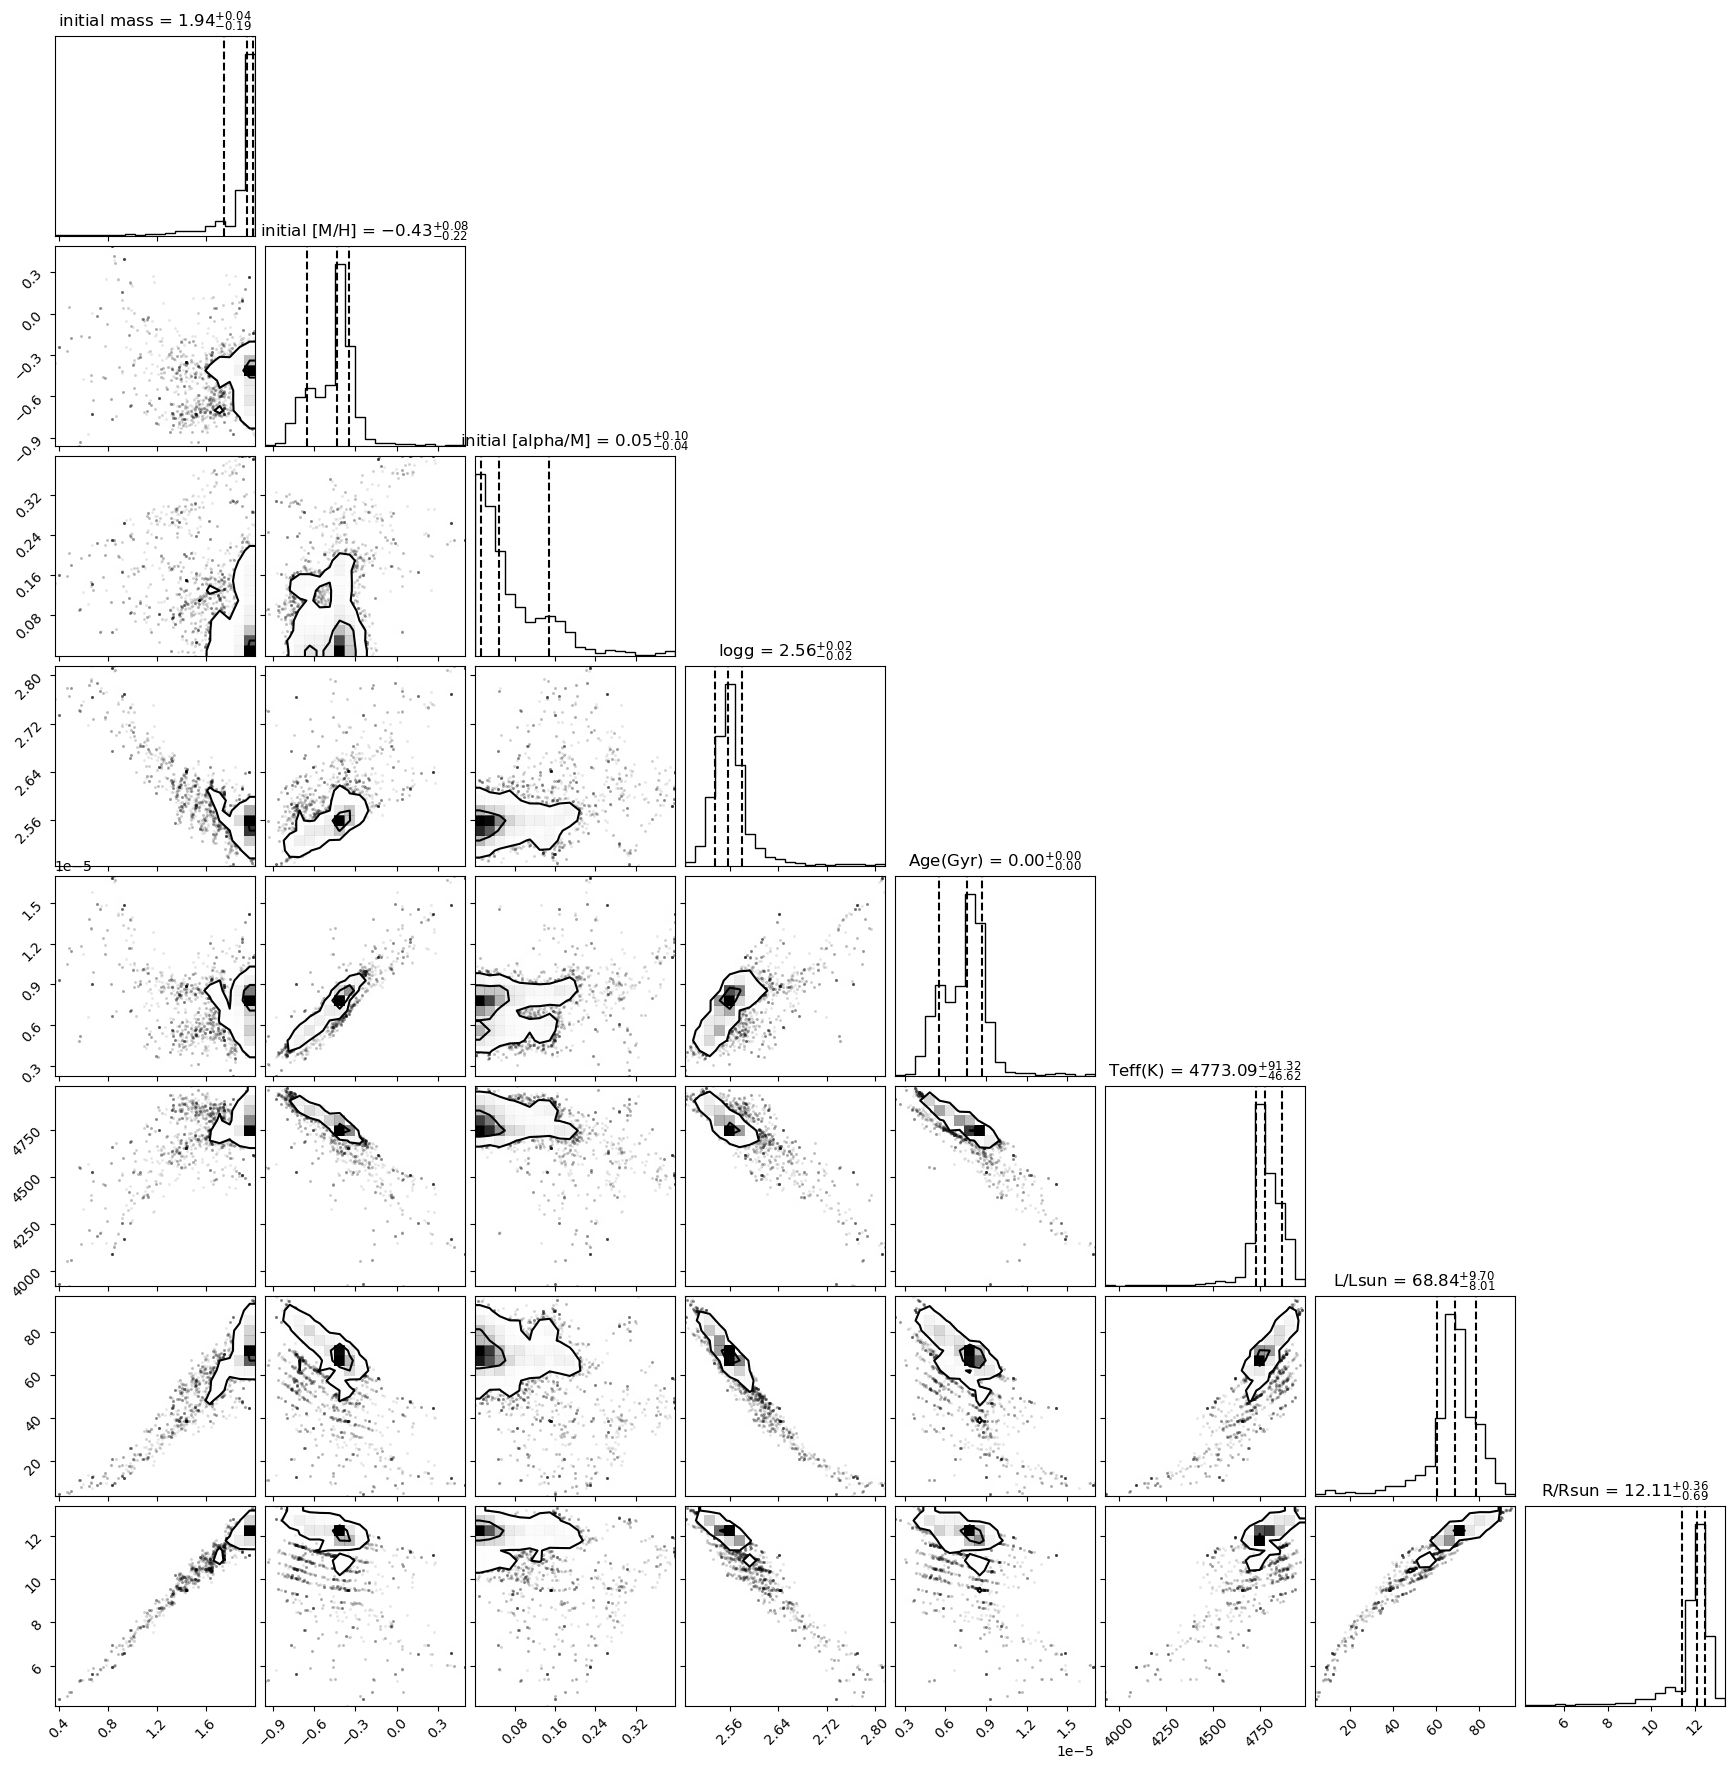

In [72]:
labels = ['initial mass', 'initial [M/H]', 'initial [alpha/M]', 'logg', 
    'Age(Gyr)', 'Teff(K)', 'L/Lsun', 'R/Rsun']
fig = corner(chains[labels], show_titles=True, titles=labels,
    quantiles=(0.16, 0.5, 0.84), levels=(1-np.exp(-2), 1-np.exp(-0.5)))